##Image categorization by Kmeans
Let's group images of digits (database contained in sklearn library) using the k-means algorithm.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits #our dataset (MNIST)
import warnings
warnings.simplefilter('ignore')

The dataset includes 1797 square images of 10 different digits (from 0 to 9). Each square image of 8×8 pixels has been reshped in a vector of 64 elements that represent the gray intensities of each pixel. That is, we have, for each image, a vector of 64 intensity values.

In [8]:
digits = load_digits()
data = digits.data

print(data.shape)

(1797, 64)


Let's visualize the first 100 examples. To improve the visualization, you can invert the gray level.

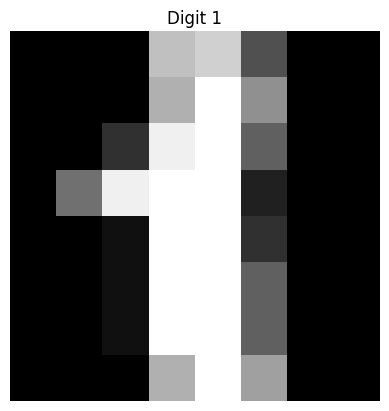

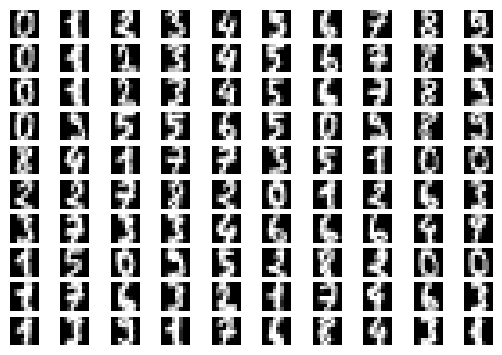

In [9]:
#data = 255-data

image = data[1]
image = image.reshape(8, 8)
plt.imshow(image, cmap='gray')
plt.title('Digit 1')
plt.axis('off')
plt.show()

num=100 #number of digits to be visualized
r = num//10    # number of rows in the figure

for k in range(0, 100):
  plt.subplot(r+1, 10, k+1)
  image = data[k]
  image = image.reshape(8, 8)
  plt.imshow(image, cmap='gray')
  plt.axis('off')
plt.show()

Now we apply Kmeans to group similar images. Since we know there are 10 different categories (from 0 to 9) we choose to group the images in 10 clusters.

In [10]:
K=10
kmeans = KMeans(n_clusters=K,init='random')
kmeans.fit(data)
Z = kmeans.predict(data) #Predict the closest cluster for each sample

Let's visualize any image and the closest cluster centroid

Image 18 belongs to cluster 0


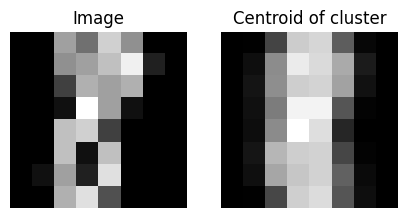

In [11]:
i=18 #choose any image
print('Image',i,'belongs to cluster',Z[i])
image = data[i]
image = image.reshape(8, 8)

c = kmeans.cluster_centers_[Z[i]]
c = c.reshape(8, 8)
fig, (ax1,ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (5, 5))
ax1.imshow(image, cmap = 'gray')
ax1.set_title('Image')
ax1.set_axis_off()
ax2.imshow(c,cmap = 'gray')
ax2.set_title('Centroid of cluster')
ax2.set_axis_off()
plt.show()

We plot all the clusters

Cluster 0
221 elements


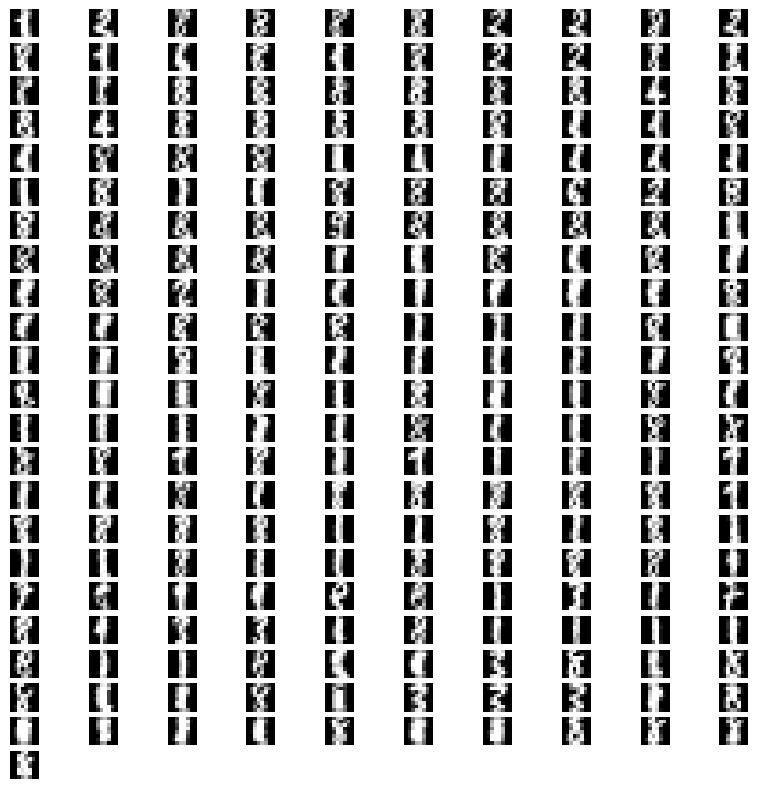

Cluster 1
92 elements


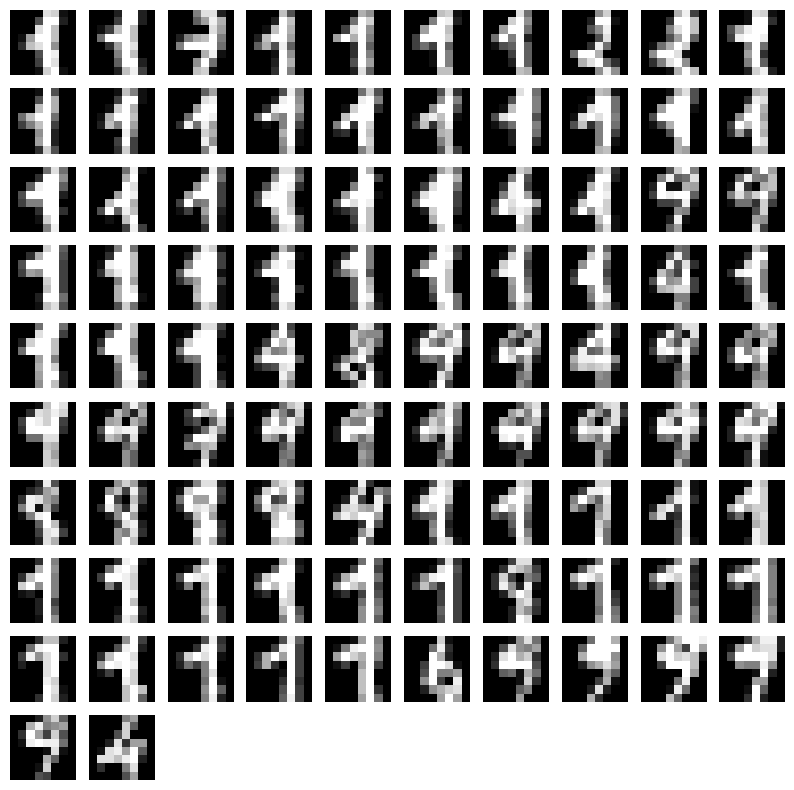

Cluster 2
150 elements


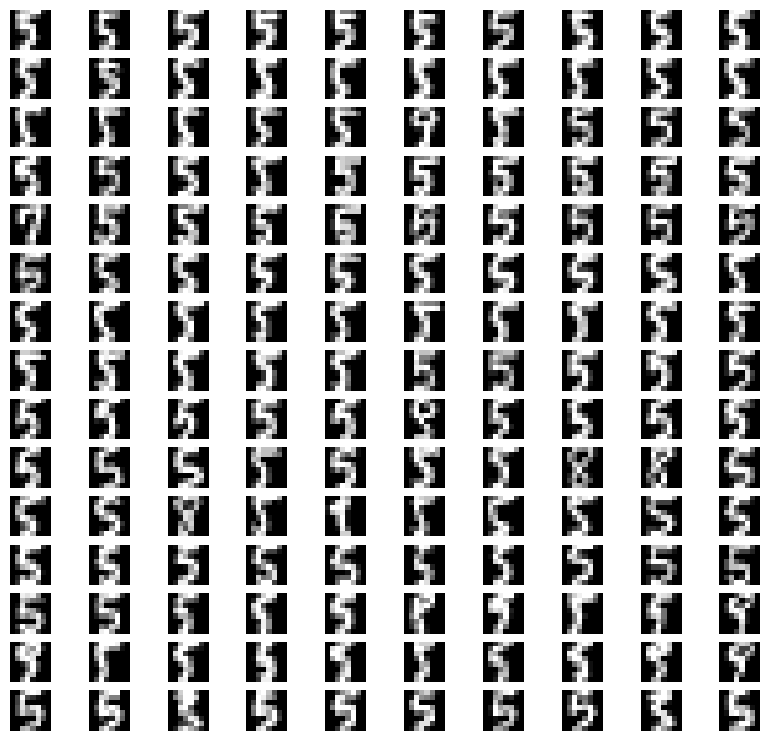

Cluster 3
166 elements


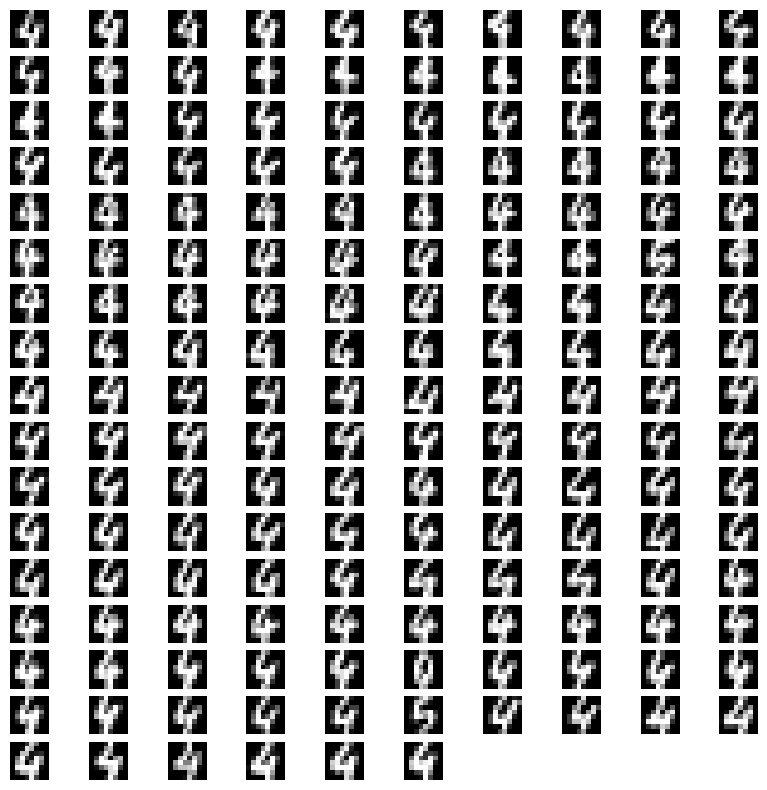

Cluster 4
174 elements


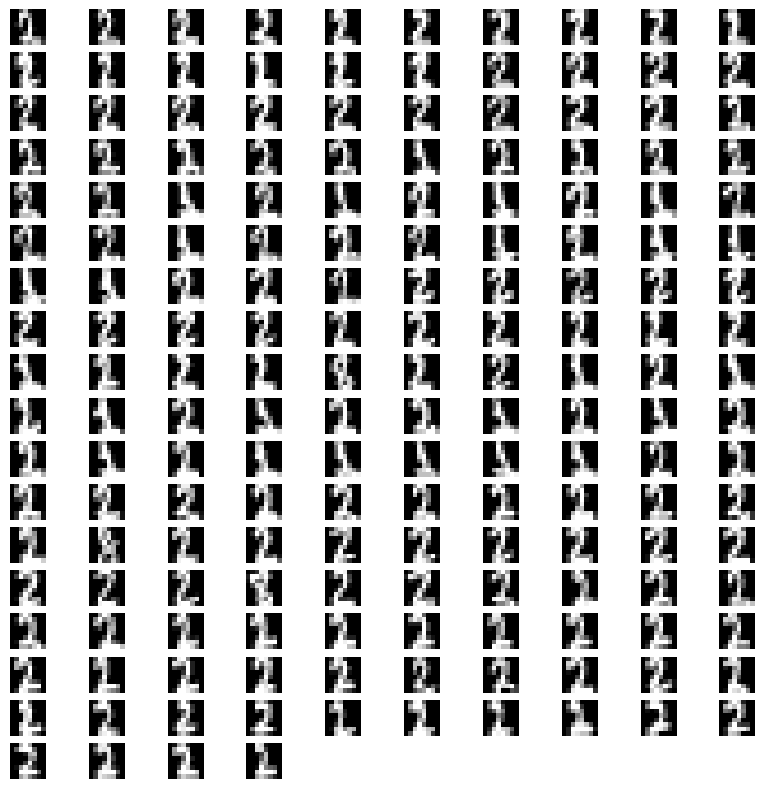

Cluster 5
177 elements


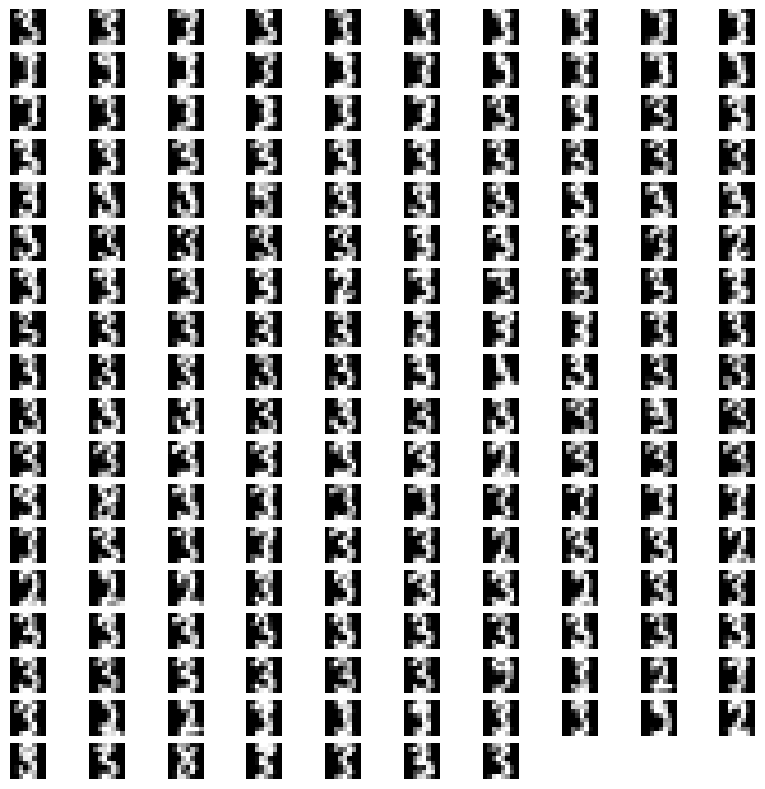

Cluster 6
208 elements


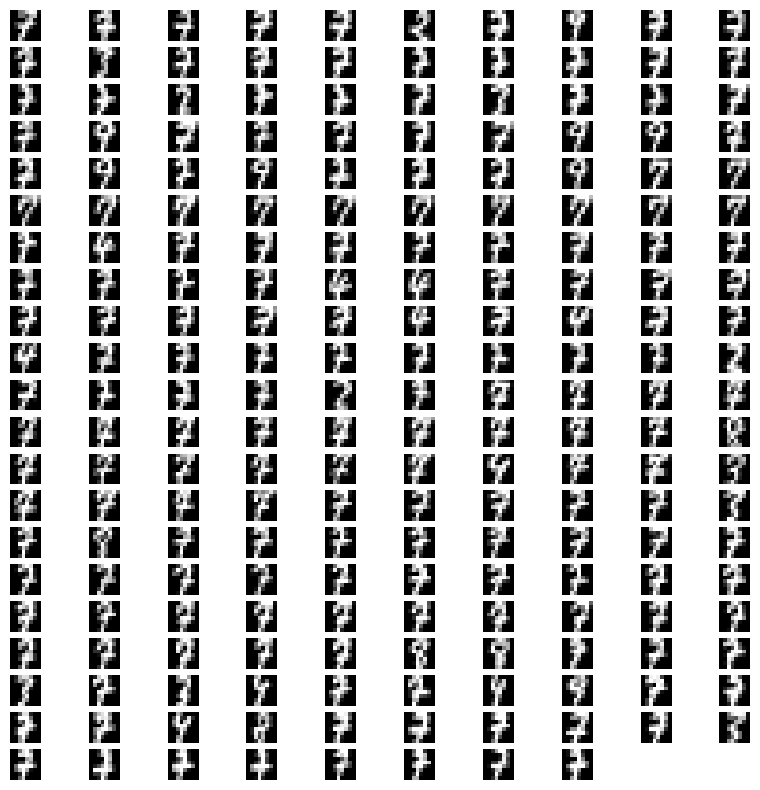

Cluster 7
248 elements


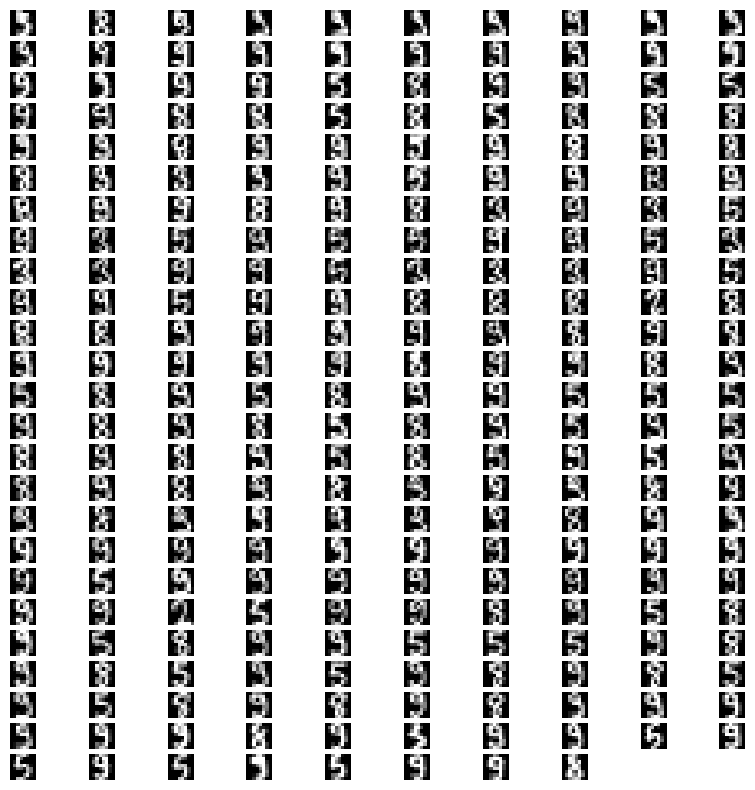

Cluster 8
179 elements


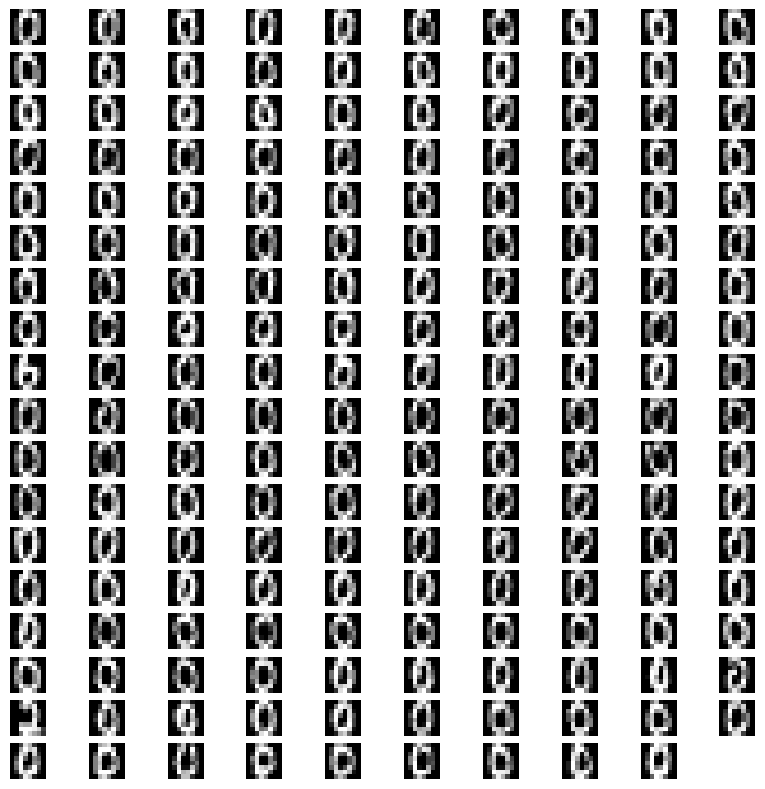

Cluster 9
182 elements


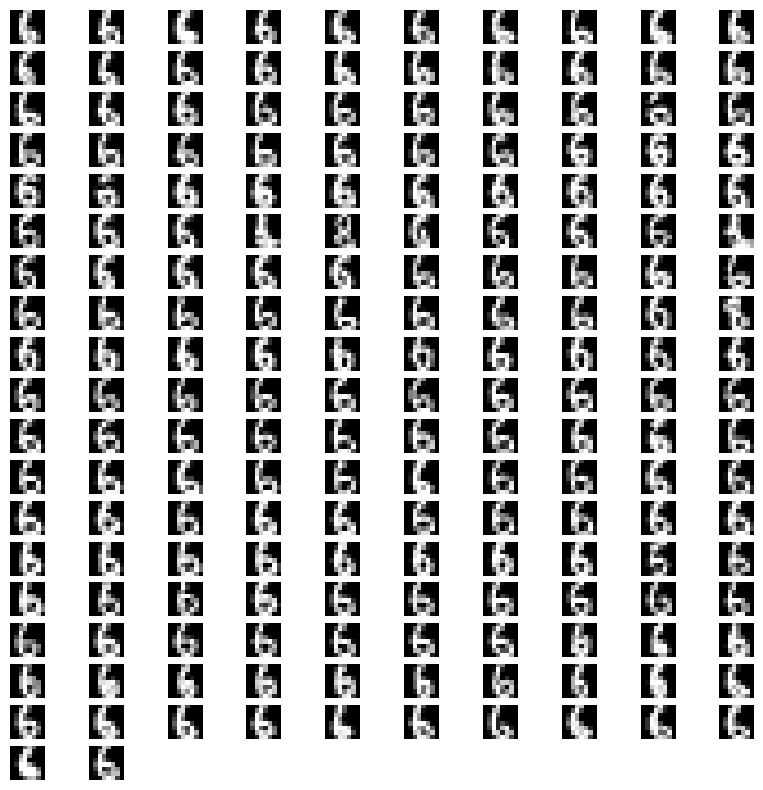

In [12]:
for i in range(0,K):

  row = np.where(Z==i)[0]  # row in Z for elements of cluster i
  num = row.shape[0]       #  number of elements for each cluster
  r = num//10    # number of rows in the figure of the cluster

  print("Cluster "+str(i))
  print(str(num)+" elements")

  plt.figure(figsize=(10,10))
  for k in range(0, num):
        plt.subplot(r+1, 10, k+1)
        image = data[row[k], ]
        image = image.reshape(8, 8)
        plt.imshow(image, cmap='gray')
        plt.axis('off')
  plt.show()